In [ ]:
# Exploratory Data Analysis & Statistical Insights

## Objective

The objective of this project is to perform comprehensive Exploratory Data Analysis (EDA) on a cleaned business transaction dataset.

The analysis focuses on:
- Descriptive statistical analysis
- Distribution analysis using histograms
- Outlier detection using box plots
- Correlation analysis using a correlation matrix and heatmap
- Multivariate analysis to identify business patterns
- Testing three business hypotheses using statistical methods
- Summarizing the key business findings and insights

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
df = pd.read_csv("clean_dataset.csv")

df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Year,Month,Month Name
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,2024,4,April
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,2023,7,July
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,2022,10,October
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,Unknown,2022,5,May
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,2022,10,October


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 12575
Columns: 14


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  str    
 1   Customer ID       12575 non-null  str    
 2   Category          12575 non-null  str    
 3   Item              12575 non-null  str    
 4   Price Per Unit    12575 non-null  float64
 5   Quantity          12575 non-null  float64
 6   Total Spent       12575 non-null  float64
 7   Payment Method    12575 non-null  str    
 8   Location          12575 non-null  str    
 9   Transaction Date  12575 non-null  str    
 10  Discount Applied  12575 non-null  str    
 11  Year              12575 non-null  int64  
 12  Month             12575 non-null  int64  
 13  Month Name        12575 non-null  str    
dtypes: float64(3), int64(2), str(9)
memory usage: 1.3 MB


In [6]:
df.describe()

,Price Per Unit,Quantity,Total Spent,Year,Month
count,12575.000000,12575.000000,12575.000000,12575.000000,12575.000000
mean,23.348191,5.558648,130.208111,2023.042386,6.366441
std,10.480413,2.790160,93.580667,0.855581,3.503156
min,5.000000,1.000000,5.000000,2022.000000,1.000000
25%,14.000000,3.000000,52.000000,2022.000000,3.000000
50%,23.000000,6.000000,110.000000,2023.000000,6.000000
75%,32.000000,8.000000,192.000000,2024.000000,9.000000
max,41.000000,10.000000,410.000000,2025.000000,12.000000


In [7]:
# Descriptive statistical Analysis
numeric_cols = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(list(numeric_cols))

Numerical columns:
['Price Per Unit', 'Quantity', 'Total Spent', 'Year', 'Month']


In [8]:
# Descriptive Statistics
df[numeric_cols].describe()

,Price Per Unit,Quantity,Total Spent,Year,Month
count,12575.000000,12575.000000,12575.000000,12575.000000,12575.000000
mean,23.348191,5.558648,130.208111,2023.042386,6.366441
std,10.480413,2.790160,93.580667,0.855581,3.503156
min,5.000000,1.000000,5.000000,2022.000000,1.000000
25%,14.000000,3.000000,52.000000,2022.000000,3.000000
50%,23.000000,6.000000,110.000000,2023.000000,6.000000
75%,32.000000,8.000000,192.000000,2024.000000,9.000000
max,41.000000,10.000000,410.000000,2025.000000,12.000000


In [9]:
summary_stats = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Standard Deviation": df[numeric_cols].std(),
    "Q1": df[numeric_cols].quantile(0.25),
    "Q3": df[numeric_cols].quantile(0.75)
})

summary_stats

,Mean,Median,Standard Deviation,Q1,Q3
Price Per Unit,23.348191,23.0,10.480413,14.0,32.0
Quantity,5.558648,6.0,2.790160,3.0,8.0
Total Spent,130.208111,110.0,93.580667,52.0,192.0
Year,2023.042386,2023.0,0.855581,2022.0,2024.0
Month,6.366441,6.0,3.503156,3.0,9.0


In [ ]:
## Descriptive Statistics Interpretation

The descriptive statistics provide an overview of the numerical variables in the dataset. Mean and median show the central tendency, while standard deviation indicates the variability of the data. The first quartile (Q1) represents the 25th percentile and the third quartile (Q3) represents the 75th percentile.

Comparing the mean and median can help identify potential skewness in transaction-related variables. A large difference between the mean and median may indicate the presence of extreme values or an uneven distribution.

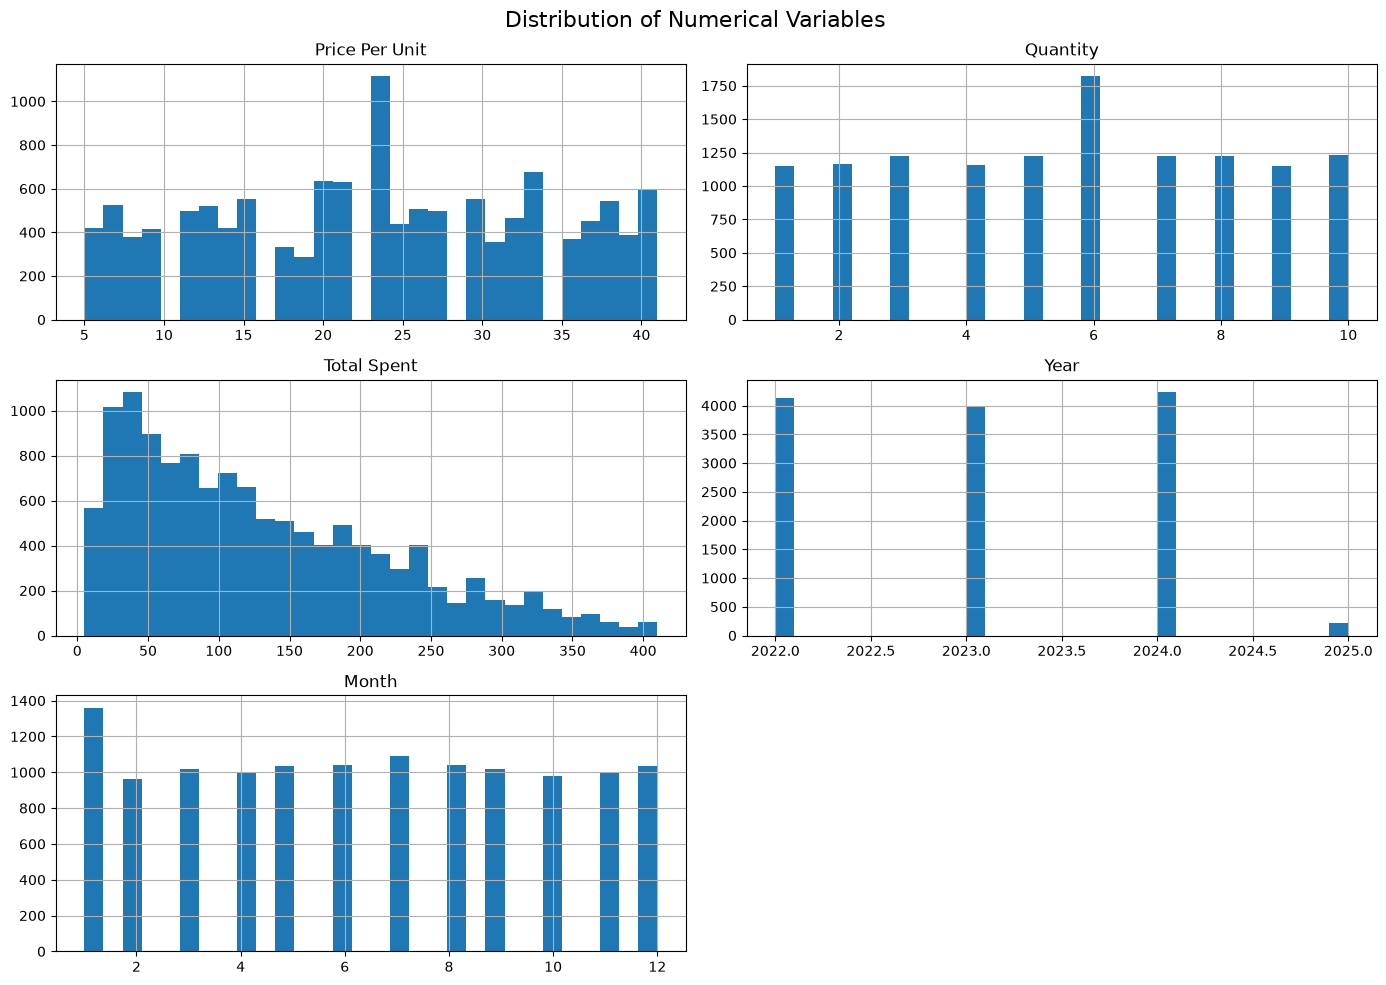

In [10]:
# Histogram Analysis
df[numeric_cols].hist(
    figsize=(14, 10),
    bins=30
)

plt.suptitle("Distribution of Numerical Variables", fontsize=16)
plt.tight_layout()
plt.show()

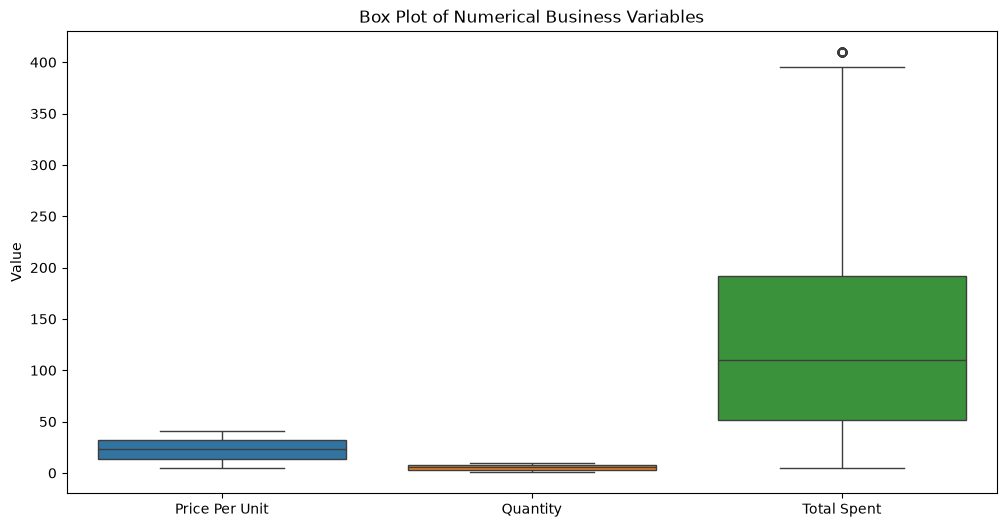

In [11]:
# Box plot
business_numeric_cols = [
    "Price Per Unit",
    "Quantity",
    "Total Spent"
]

plt.figure(figsize=(12, 6))

sns.boxplot(data=df[business_numeric_cols])

plt.title("Box Plot of Numerical Business Variables")
plt.ylabel("Value")
plt.xticks(rotation=0)

plt.show()

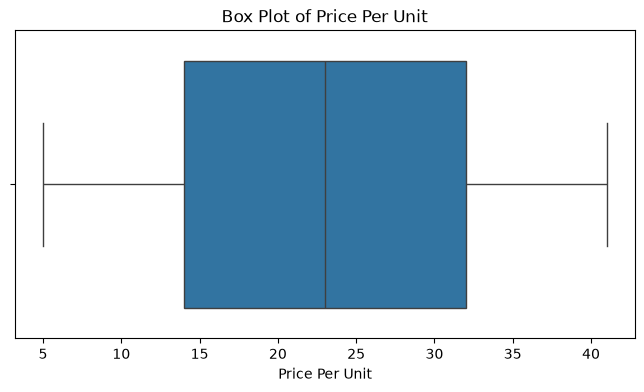

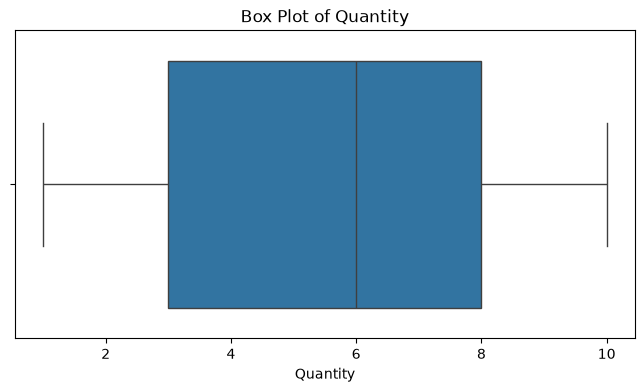

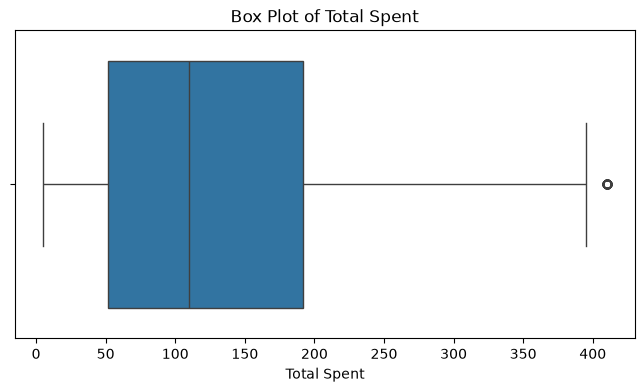

In [12]:
for column in business_numeric_cols:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(x=df[column])
    
    plt.title(f"Box Plot of {column}")
    plt.xlabel(column)
    
    plt.show()

In [ ]:
## Box Plot and Outlier Analysis

Box plots were used to identify the spread of numerical variables and detect potential outliers.

The box plots show the median, interquartile range (IQR), and potential extreme observations. Variables with observations beyond the whiskers may contain potential outliers.

Outliers should not automatically be removed because they may represent genuine high-value business transactions. Therefore, they should be investigated before deciding whether they are errors or meaningful observations.

In [13]:
# Correlation Matrix
correlation_matrix = df[business_numeric_cols].corr()

correlation_matrix

,Price Per Unit,Quantity,Total Spent
Price Per Unit,1.000000,0.011306,0.625595
Quantity,0.011306,1.000000,0.703938
Total Spent,0.625595,0.703938,1.000000


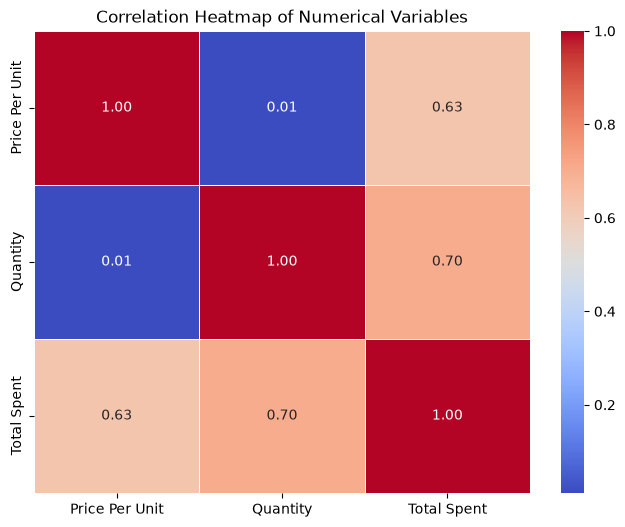

In [14]:
# Correlation Hitmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

In [ ]:
## Correlation Analysis

The correlation matrix was used to examine linear relationships between the numerical business variables.

The heatmap provides a visual representation of the strength and direction of these relationships. Strong positive correlations indicate that two variables tend to increase together, while negative correlations indicate an inverse relationship.

The correlation results will also help identify variables that may be useful for further business analysis and hypothesis testing.

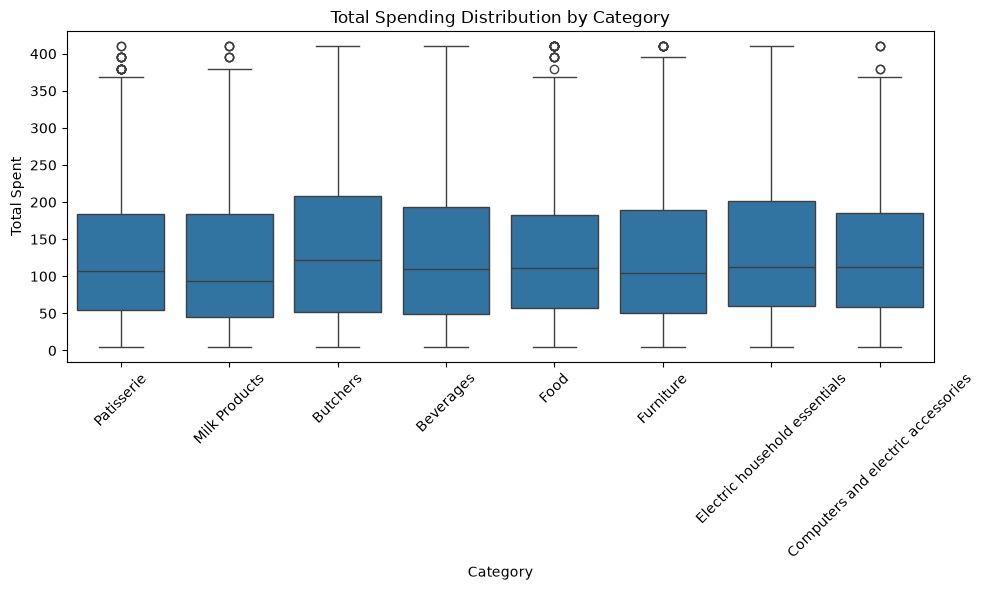

In [15]:
# Multivariate Analysis - Total spending by category
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Category",
    y="Total Spent"
)

plt.title("Total Spending Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Total Spent")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

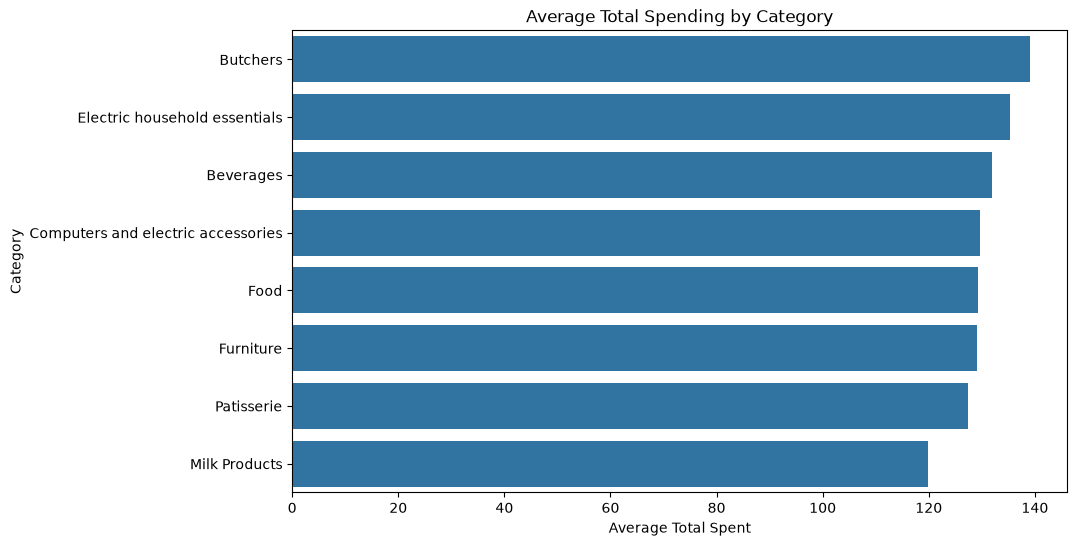

In [16]:
# Avg spending by category
category_spending = (
    df.groupby("Category")["Total Spent"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_spending.values,
    y=category_spending.index
)

plt.title("Average Total Spending by Category")
plt.xlabel("Average Total Spent")
plt.ylabel("Category")

plt.show()

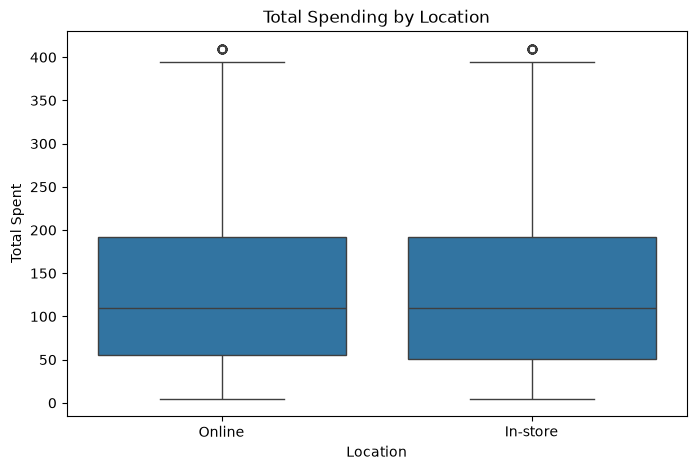

In [17]:
# Spending by location
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Location",
    y="Total Spent"
)

plt.title("Total Spending by Location")
plt.xlabel("Location")
plt.ylabel("Total Spent")

plt.show()

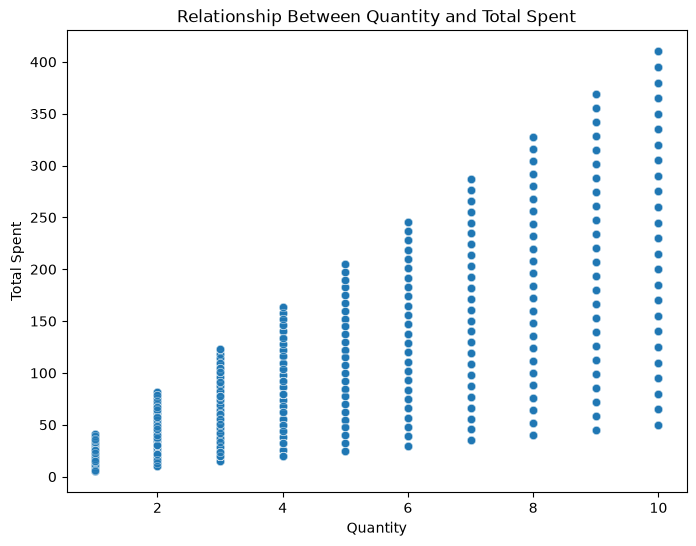

In [18]:
# Quantity v/s total spend
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="Total Spent",
    alpha=0.5
)

plt.title("Relationship Between Quantity and Total Spent")
plt.xlabel("Quantity")
plt.ylabel("Total Spent")

plt.show()


In [ ]:
## Multivariate Analysis

Multivariate visualizations were used to examine relationships between multiple business variables.

The analysis compares total spending across different product categories and locations and examines the relationship between quantity purchased and total spending.

These visualizations help identify differences in customer spending behavior and reveal potential relationships that cannot be observed from individual variables alone.

In [6]:
# Hypothesis 1 - Discount v/s Total spent
discount_data = df[df["Discount Applied"].isin(["True", "False"])].copy()

discount_data["Discount Applied"].value_counts()

Discount Applied
True     4219
False    4157
Name: count, dtype: int64

In [7]:
# Define Groups
discount_yes = discount_data[
    discount_data["Discount Applied"] == "True"
]["Total Spent"]

discount_no = discount_data[
    discount_data["Discount Applied"] == "False"
]["Total Spent"]

In [8]:
# Independent t- test
t_stat, p_value = stats.ttest_ind(
    discount_yes,
    discount_no,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.08640821812417782
P-value: 0.9311439802205668


In [9]:
# Decision
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in average spending between discounted and non-discounted transactions.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in average spending between discounted and non-discounted transactions.")

Fail to reject the null hypothesis.
There is no statistically significant difference in average spending between discounted and non-discounted transactions.


In [ ]:
## Hypothesis 1: Discount and Total Spending

**Null Hypothesis (H₀):** There is no significant difference in average total spending between transactions with discounts and transactions without discounts.

**Alternative Hypothesis (H₁):** There is a significant difference in average total spending between transactions with discounts and transactions without discounts.

An independent samples t-test was performed using a significance level of 0.05.

The p-value was evaluated against the significance level to determine whether the observed difference in spending is statistically significant.

In [10]:
# Hypothesis 2: Online vs In-store Spending
online_spending = df[
    df["Location"] == "Online"
]["Total Spent"]

instore_spending = df[
    df["Location"] == "In-store"
]["Total Spent"]

In [11]:
# t - test
t_stat2, p_value2 = stats.ttest_ind(
    online_spending,
    instore_spending,
    equal_var=False
)

print("T-statistic:", t_stat2)
print("P-value:", p_value2)

T-statistic: 0.8728420084519738
P-value: 0.38276587632799436


In [13]:
# Decision
if p_value2 < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in average spending between Online and In-store transactions.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in average spending between Online and In-store transactions.")

Fail to reject the null hypothesis.
There is no statistically significant difference in average spending between Online and In-store transactions.


In [ ]:
## Hypothesis 2: Location and Total Spending

**Null Hypothesis (H₀):** There is no significant difference in average total spending between Online and In-store transactions.

**Alternative Hypothesis (H₁):** There is a significant difference in average total spending between Online and In-store transactions.

An independent samples t-test was used to compare the two groups at a significance level of 0.05.

In [15]:
# Hypothesis 3: Category and Total Spending
category_groups = [
    group["Total Spent"].values
    for name, group in df.groupby("Category")
]

In [16]:
# ANOVA test
f_stat, p_value3 = stats.f_oneway(*category_groups)

print("F-statistic:", f_stat)
print("P-value:", p_value3)

F-statistic: 5.841274416848758
P-value: 8.725064821013417e-07


In [17]:
# Decision
if p_value3 < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in average spending among product categories.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in average spending among product categories.")

Reject the null hypothesis.
There is a statistically significant difference in average spending among product categories.


In [ ]:
## Hypothesis 3: Category and Total Spending

**Null Hypothesis (H₀):** The average total spending is the same across all product categories.

**Alternative Hypothesis (H₁):** At least one product category has a different average total spending.

A one-way ANOVA test was performed to determine whether the differences in average spending across categories are statistically significant.

The p-value was compared with the significance level of 0.05.

In [18]:
# Hypothesis test summary
hypothesis_summary = pd.DataFrame({
    "Hypothesis": [
        "Discount vs Total Spent",
        "Online vs In-store Spending",
        "Category vs Total Spent"
    ],
    "Test": [
        "Independent t-test",
        "Independent t-test",
        "One-way ANOVA"
    ],
    "P-value": [
        p_value,
        p_value2,
        p_value3
    ]
})

hypothesis_summary["Significance"] = hypothesis_summary["P-value"].apply(
    lambda x: "Significant" if x < 0.05 else "Not Significant"
)

hypothesis_summary

,Hypothesis,Test,P-value,Significance
0,Discount vs Total Spent,Independent t-test,9.311440e-01,Not Significant
1,Online vs In-store Spending,Independent t-test,3.827659e-01,Not Significant
2,Category vs Total Spent,One-way ANOVA,8.725065e-07,Significant


In [19]:
print("Average Total Spent by Discount Status:")
print(
    discount_data.groupby("Discount Applied")["Total Spent"].mean()
)

print("\nAverage Total Spent by Location:")
print(
    df.groupby("Location")["Total Spent"].mean()
)

print("\nAverage Total Spent by Category:")
print(
    df.groupby("Category")["Total Spent"]
      .mean()
      .sort_values(ascending=False)
)

Average Total Spent by Discount Status:
Discount Applied
False    130.796728
True     130.972861
Name: Total Spent, dtype: float64

Average Total Spent by Location:
Location
In-store    129.471950
Online      130.928864
Name: Total Spent, dtype: float64

Average Total Spent by Category:
Category
Butchers                              139.128189
Electric household essentials         135.322124
Beverages                             132.006701
Computers and electric accessories    129.668485
Food                                  129.234887
Furniture                             129.094909
Patisserie                            127.311191
Milk Products                         119.881313
Name: Total Spent, dtype: float64


In [ ]:
#Top 5 Critical Business Findings
# Top 5 Critical Business Findings

### 1. Product category has a significant impact on total spending
The one-way ANOVA test produced a p-value of 8.725065e-07, which is below the significance level of 0.05. Therefore, there is a statistically significant difference in average total spending across product categories.

The Butchers category has the highest average total spending at approximately 139.13, while Milk Products has the lowest at approximately 119.88.

### 2. Discounted and non-discounted transactions have almost identical spending
The average total spending for discounted transactions is 130.97, compared with 130.80 for non-discounted transactions. The difference is very small, and the t-test produced a p-value of 0.9311.

Therefore, discount status does not show a statistically significant difference in average transaction spending in this dataset.

### 3. Online and in-store transactions show similar spending levels
Online transactions have an average total spending of 130.93, while in-store transactions have an average of 129.47.

The independent t-test produced a p-value of 0.3828, indicating that the difference is not statistically significant.

### 4. Butchers and Electric Household Essentials are the highest-spending categories
The Butchers category has the highest average total spending (139.13), followed by Electric Household Essentials (135.32) and Beverages (132.01).

These categories may represent important revenue opportunities and could be investigated further to understand their customer demand and purchasing patterns.

### 5. Milk Products has the lowest average transaction spending
Milk Products has the lowest average total spending at approximately 119.88, which is lower than all other analyzed categories.

This may indicate differences in product pricing, quantity purchased, or customer purchasing behavior and could be investigated further for business decision-making.

In [ ]:
# Conclusion

The Exploratory Data Analysis provided several insights into the business transaction dataset.

Descriptive statistics and distribution plots helped understand the central tendency, spread, and distribution of the numerical variables. Box plots were used to identify potential outliers, while the correlation analysis examined relationships between numerical business variables.

The hypothesis testing showed that discount status and sales location did not have statistically significant effects on average total spending. However, product category showed a statistically significant difference in average total spending.

Among the categories, Butchers had the highest average transaction spending, while Milk Products had the lowest. These findings can help businesses identify categories with different spending patterns and focus further analysis on category-level customer behavior.

Overall, the analysis demonstrates how statistical methods and data visualization can be used to identify meaningful business patterns and support data-driven decision-making.